In [ ]:
# =========================
# CELL 1: IMPORT LIBRARY
# =========================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import zipfile

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    concatenate, BatchNormalization, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow.keras.backend as K

from google.colab import drive, files
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

drive.mount('/content/drive')
print('TF Version:', tf.__version__)


Mounted at /content/drive
TF Version: 2.20.0


In [ ]:
# =========================# CELL 2: LOAD DATA# =========================

# Mengubah ukuran gambar menjadi 128
IMG_SIZE = 128

def load_data(image_path, mask_path):
    images, masks = [], []
    img_files  = sorted(os.listdir(image_path))
    mask_files = sorted(os.listdir(mask_path))

    for img_file, mask_file in zip(img_files, mask_files):
        img  = cv2.imread(os.path.join(image_path,  img_file),  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(mask_path, mask_file), cv2.IMREAD_GRAYSCALE)

        img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE)) / 255.0
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0

        # FIX: pastikan mask benar-benar biner [0, 1]
        mask = (mask > 0.5).astype(np.float32)

        # Komentar dimensi otomatis menyesuaikan dengan IMG_SIZE (128,128,1)
        images.append(np.expand_dims(img,  axis=-1))
        masks.append( np.expand_dims(mask, axis=-1))

    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)


train_img_path  = '/content/drive/MyDrive/mammogram_project/images/train'
train_mask_path = '/content/drive/MyDrive/mammogram_project/masks/train'
test_img_path   = '/content/drive/MyDrive/mammogram_project/images/test'
test_mask_path  = '/content/drive/MyDrive/mammogram_project/masks/test'

# Langsung load ke X_train & y_train tanpa perlu split lagi
X_train, y_train = load_data(train_img_path, train_mask_path)
X_test,  y_test  = load_data(test_img_path,  test_mask_path)

# Print output disesuaikan hanya untuk Train dan Test
print('Train     :', X_train.shape, y_train.shape)
print('Test      :', X_test.shape,  y_test.shape)
print('Mask range:', y_train.min(), '-', y_train.max(),
      '| Positive pixel ratio:', y_train.mean().round(4))

Train     : (723, 128, 128, 1) (723, 128, 128, 1)
Test      : (181, 128, 128, 1) (181, 128, 128, 1)
Mask range: 0.0 - 1.0 | Positive pixel ratio: 0.1098


In [ ]:
# =========================
# CELL 3: LOSS FUNCTIONS
# FIX UTAMA: Ganti MSE dengan Dice Loss + Binary Crossentropy
# =========================

def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice Loss untuk segmentasi — lebih baik dari MSE untuk mask biner."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1.0 - (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    """Kombinasi Binary Crossentropy + Dice Loss (standar medis imaging)."""
    bce  = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

def dice_coef_metric(y_true, y_pred, smooth=1e-6):
    """Dice Coefficient sebagai metric monitoring saat training."""
    y_true_f = K.flatten(K.cast(y_true > 0.5, 'float32'))
    y_pred_f = K.flatten(K.cast(y_pred > 0.5, 'float32'))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )

print('Loss functions siap.')


Loss functions siap.


In [ ]:
# =========================
# CELL 4: BUILD U-NET
# =========================

def conv_block(x, filters):
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

# UBAH DISINI: Default input_shape diganti menjadi (128, 128, 1)
def build_unet(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 32);  p1 = MaxPooling2D((2, 2))(c1)
    c2 = conv_block(p1, 64);      p2 = MaxPooling2D((2, 2))(c2)
    c3 = conv_block(p2, 128);     p3 = MaxPooling2D((2, 2))(c3)

    # Bottleneck
    b = conv_block(p3, 256)

    # Decoder
    u1 = UpSampling2D((2, 2))(b);  u1 = concatenate([u1, c3])
    d1 = conv_block(u1, 128)
    u2 = UpSampling2D((2, 2))(d1); u2 = concatenate([u2, c2])
    d2 = conv_block(u2, 64)
    u3 = UpSampling2D((2, 2))(d2); u3 = concatenate([u3, c1])
    d3 = conv_block(u3, 32)

    # Output: 1 channel, sigmoid → probabilitas [0,1] per pixel
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(d3)

    return Model(inputs, outputs, name='UNet')


# Sekarang model akan otomatis nge-build dengan struktur 128x128x1
unet_model = build_unet()

# FIX UTAMA: gunakan bce_dice_loss bukan 'mse'
unet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef_metric]
)

unet_model.summary()

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 1,951,937 (7.45 MB)

 Trainable params: 1,949,121 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
# =========================# CELL 5: TRAINING U-NET# =========================

callbacks_unet = [

    EarlyStopping(patience=10, restore_best_weights=True, monitor='dice_coef_metric', mode='max'),
    ModelCheckpoint('/content/unet_best_final.keras', save_best_only=True,
                    monitor='dice_coef_metric', mode='max'),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

history_unet = unet_model.fit(
    X_train, y_train,

    epochs=50,
    batch_size=8,
    callbacks=callbacks_unet
)

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 438s 5s/step - dice_coef_metric: 0.3977 - loss: 1.1389 - learning_rate: 1.0000e-04
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 433s 5s/step - dice_coef_metric: 0.4787 - loss: 1.0112 - learning_rate: 1.0000e-04
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 434s 4s/step - dice_coef_metric: 0.4912 - loss: 0.9637 - learning_rate: 1.0000e-04
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - dice_coef_metric: 0.4990 - loss: 0.9320 - learning_rate: 1.0000e-04
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 443s 4s/step - dice_coef_metric: 0.5037 - loss: 0.9111 - learning_rate: 1.0000e-04
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - dice_coef_metric: 0.5034 - loss: 0.8980 - learning_rate: 1.0000e-04
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 407s 4s/step - dice_coef_metric: 0.5089 - loss: 0.8863 - learning_rate: 1.0000e-04
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 441s 4s/step - dice_coef_metric: 0.5073 - loss: 0.8807 - learning_rate: 1.0000e-04
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━

In [ ]:
# =========================# CELL 6: BUILD CAE# FIX: Output layer harus Conv2D(1) bukan Conv2D(256)# =========================

# UBAH DISINI: Default input_shape diganti menjadi (128, 128, 1)
def build_cae(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)

    # Encoder
    x = Conv2D(32,  (3,3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2,2))(x)     # Dimensi turun jadi: 64x64
    x = Conv2D(64,  (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)     # Dimensi turun jadi: 32x32
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)     # Dimensi turun jadi: 16x16

    # Bottleneck
    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)  # representasi (16x16)

    # Decoder
    x = UpSampling2D((2,2))(x)     # Dimensi naik jadi: 32x32
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)     # Dimensi naik jadi: 64x64
    x = Conv2D(64,  (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)     # Dimensi naik jadi: 128x128
    x = Conv2D(32,  (3,3), activation='relu', padding='same')(x)

    # FIX UTAMA: Output harus 1 channel sigmoid, bukan 256!
    outputs = Conv2D(1, (1,1), activation='sigmoid', padding='same')(x)

    return Model(inputs, outputs, name='CAE')


# Sekarang model akan otomatis terbentuk dengan struktur 128x128
cae_model = build_cae()

# CAE dilatih untuk rekonstruksi → MSE sudah benar di sini
cae_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse'
)

cae_model.summary()

# Output shape sekarang harus (None, 128, 128, 1)
print('Output shape CAE:', cae_model.output_shape)

Model: "CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,169 (2.96 MB)

 Trainable params: 775,169 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

Output shape CAE: (None, 128, 128, 1)


In [ ]:
# =========================# CELL 7: TRAINING CAE# CAE hanya dilatih dengan gambar NORMAL (tanpa kanker)# sehingga bisa mendeteksi anomali saat ada kanker# =========================# Gunakan semua data train (CAE belajar merekonstruksi gambar normal)# Jika punya label normal/kanker, idealnya filter hanya gambar normal:# X_train_normal = X_train[y_train_label == 0]

callbacks_cae = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss', mode='min'),
    ModelCheckpoint('/content/cae_best_final.keras', save_best_only=True, monitor='val_loss', mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

history_cae = cae_model.fit(
    X_train, X_train,       # input = target (rekonstruksi gambar 128x128)
    # UBAH DISINI: Ganti validation_data dengan validation_split
    validation_split=0.2,
    epochs=50,
    batch_size=8,
    callbacks=callbacks_cae
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - loss: 0.0285 - val_loss: 0.0061 - learning_rate: 1.0000e-04
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - loss: 0.0039 - val_loss: 0.0027 - learning_rate: 1.0000e-04
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0021 - val_loss: 0.0019 - learning_rate: 1.0000e-04
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0017 - val_loss: 0.0016 - learning_rate: 1.0000e-04
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - loss: 0.0014 - val_loss: 0.0014 - learning_rate: 1.0000e-04
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - loss: 0.0013 - val_loss: 0.0014 - learning_rate: 1.0000e-04
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - loss: 0.0011 - val_loss: 0.0012 - learning_rate: 1.0000e-04
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - loss: 0.0012 - val_loss: 0.0012 - learning_rate: 1.0000e-04
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 9.8599e-04 - val_loss: 9.5302e-04 - l

In [ ]:
# =========================# CELL 8: EVALUASI LENGKAP# Dice, IoU, Precision, Recall, F1, Accuracy# =========================
print('🔄 Menghitung metrik evaluasi...\n')

# FIX UTAMA: Pastikan library metrics dari sklearn sudah ter-import
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ── Fungsi helper ──────────────────────────────────────────
def dice_score_np(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_score_np(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# ── U-Net Prediksi ─────────────────────────────────────────
pred_unet  = unet_model.predict(X_test, verbose=0)          # Ukuran (N,128,128,1) float
binary_pred = (pred_unet > 0.5).astype(np.uint8)            # threshold
y_true_bin  = (y_test  > 0.5).astype(np.uint8)

# Metrik U-Net
dice_unet      = dice_score_np(y_true_bin, binary_pred)
iou_unet       = iou_score_np(y_true_bin, binary_pred)

y_true_flat = y_true_bin.flatten()
y_pred_flat = binary_pred.flatten()

precision_unet = precision_score(y_true_flat, y_pred_flat, zero_division=0)
recall_unet    = recall_score(   y_true_flat, y_pred_flat, zero_division=0)
f1_unet        = f1_score(       y_true_flat, y_pred_flat, zero_division=0)
accuracy_unet  = accuracy_score( y_true_flat, y_pred_flat)

print('=' * 45)
print('           U-NET EVALUATION METRICS')
print('=' * 45)
print(f'  Dice Score  : {dice_unet:.4f}')
print(f'  IoU Score   : {iou_unet:.4f}')
print(f'  Precision   : {precision_unet:.4f}')
print(f'  Recall      : {recall_unet:.4f}')
print(f'  F1 Score    : {f1_unet:.4f}')
print(f'  Accuracy    : {accuracy_unet:.4f}')
print('=' * 45)

# ── CAE Prediksi ───────────────────────────────────────────
pred_cae  = cae_model.predict(X_test, verbose=0)            # Ukuran (N,128,128,1)

# FIX: pastikan shape sama sebelum substraksi
assert X_test.shape == pred_cae.shape, \
    f'Shape mismatch! X_test={X_test.shape}, pred_cae={pred_cae.shape}'

error_cae      = np.abs(X_test - pred_cae)                  # per-pixel error
anomaly_score  = float(np.mean(error_cae))                  # rata-rata global
anomaly_per_img = np.mean(error_cae, axis=(1,2,3))          # per gambar

# Threshold CAE: gambar dengan error > mean+std dianggap anomali
threshold_cae  = anomaly_per_img.mean() + anomaly_per_img.std()
pred_cae_label = (anomaly_per_img > threshold_cae).astype(int)

print()
print('=' * 45)
print('           CAE EVALUATION METRICS')
print('=' * 45)
print(f'  Anomaly Score (mean)  : {anomaly_score:.6f}')
print(f'  Anomaly Score (%)     : {anomaly_score*100:.4f}%')
print(f'  Threshold Anomali     : {threshold_cae:.6f}')
print(f'  Gambar Terdeteksi     : {pred_cae_label.sum()} dari {len(pred_cae_label)}')
print('=' * 45)
print()
print('✅ Evaluasi selesai!')

# Simpan variabel global untuk cell download
globals().update({
    'dice_unet': dice_unet, 'iou_unet': iou_unet,
    'precision_unet': precision_unet, 'recall_unet': recall_unet,
    'f1_unet': f1_unet, 'accuracy_unet': accuracy_unet,
    'anomaly_score': anomaly_score, 'threshold_cae': threshold_cae
})

🔄 Menghitung metrik evaluasi...

           U-NET EVALUATION METRICS
  Dice Score  : 0.4186
  IoU Score   : 0.2647
  Precision   : 0.5254
  Recall      : 0.3479
  F1 Score    : 0.4186
  Accuracy    : 0.8955

           CAE EVALUATION METRICS
  Anomaly Score (mean)  : 0.014779
  Anomaly Score (%)     : 1.4779%
  Threshold Anomali     : 0.017578
  Gambar Terdeteksi     : 31 dari 181

✅ Evaluasi selesai!


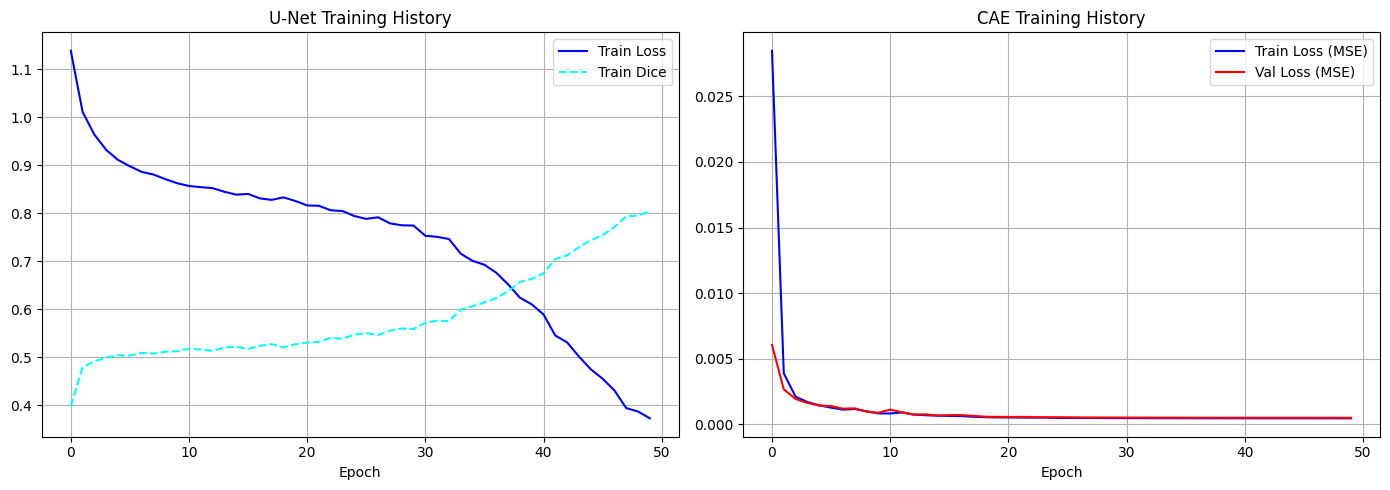

Plot kurva training berhasil dibuat dan disimpan di /content/training_curves.png.


In [ ]:
# =========================
# CELL 9: VISUALISASI KURVA TRAINING
# =========================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── U-Net Loss & Dice ─────────────────────────────────────
ax = axes[0]
if 'loss' in history_unet.history:
    ax.plot(history_unet.history['loss'], label='Train Loss', color='blue')
if 'val_loss' in history_unet.history:
    ax.plot(history_unet.history['val_loss'], label='Val Loss', color='red')

# Cek penamaan metrik dice (bisa jadi dice_coef_metric atau val_dice_coef_metric)
dice_key = 'dice_coef_metric' if 'dice_coef_metric' in history_unet.history else 'dice_coef'
val_dice_key = 'val_' + dice_key

if dice_key in history_unet.history:
    ax.plot(history_unet.history[dice_key], label='Train Dice', linestyle='--', color='cyan')
if val_dice_key in history_unet.history:
    ax.plot(history_unet.history[val_dice_key], label='Val Dice', linestyle='--', color='orange')

ax.set_title('U-Net Training History')
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(True)

# ── CAE Loss ──────────────────────────────────────────────
ax = axes[1]
if 'loss' in history_cae.history:
    ax.plot(history_cae.history['loss'], label='Train Loss (MSE)', color='blue')
if 'val_loss' in history_cae.history:
    ax.plot(history_cae.history['val_loss'], label='Val Loss (MSE)', color='red')

ax.set_title('CAE Training History')
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Plot kurva training berhasil dibuat dan disimpan di /content/training_curves.png.')

In [ ]:
# =========================# CELL 10: DOWNLOAD SEMUA HASIL# =========================
import os, zipfile
from google.colab import files as colab_files

output_dir = '/content/mammogram_models'
os.makedirs(output_dir, exist_ok=True)

# Copy model .keras dan plot kurva ke folder output
os.system(f'cp /content/unet_best_final.keras {output_dir}/unet_best_final.keras')
os.system(f'cp /content/cae_best_final.keras  {output_dir}/cae_best_final.keras')
os.system(f'cp /content/training_curves.png   {output_dir}/training_curves.png')

# Tulis metrik lengkap ke file teks hasil evaluasi gambar ukuran 128
with open(f'{output_dir}/evaluation_metrics.txt', 'w') as f:
    f.write('=' * 45 + '\n')
    f.write('       U-NET EVALUATION METRICS (SIZE 128)\n')
    f.write('=' * 45 + '\n')
    f.write(f'Dice Score  : {dice_unet:.4f}\n')
    f.write(f'IoU Score   : {iou_unet:.4f}\n')
    f.write(f'Precision   : {precision_unet:.4f}\n')
    f.write(f'Recall      : {recall_unet:.4f}\n')
    f.write(f'F1 Score    : {f1_unet:.4f}\n')
    f.write(f'Accuracy    : {accuracy_unet:.4f}\n')
    f.write('\n')
    f.write('=' * 45 + '\n')
    f.write('       CAE EVALUATION METRICS (SIZE 128)\n')
    f.write('=' * 45 + '\n')
    f.write(f'Anomaly Score (mean) : {anomaly_score:.6f}\n')
    f.write(f'Anomaly Score (%)    : {anomaly_score*100:.4f}%\n')
    f.write(f'Threshold Anomali    : {threshold_cae:.6f}\n')

print('Isi folder output:')
for f in os.listdir(output_dir):
    print(' ', f)

# Buat ZIP untuk mempermudah download sekaligus
zip_path = '/content/mammogram_models.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, fnames in os.walk(output_dir):
        for fname in fnames:
            full = os.path.join(root, fname)
            zipf.write(full, os.path.relpath(full, output_dir))

print('\n✅ mammogram_models.zip siap diunduh!')
colab_files.download(zip_path)

Isi folder output:
  unet_best_final.keras
  cae_best_final.keras
  training_curves.png
  evaluation_metrics.txt

✅ mammogram_models.zip siap diunduh!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>